#### Using auto regression to answer: What is the forecasted incidence of OHCA till year 2040, based on Pan-Asian Resuscitation Outcomes Study (PAROS) data?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sn
from statsmodels.tsa.ar_model import AutoReg


In [3]:
# read from the collated incident count csv
OHCA_incident_count = pd.read_csv("../../datasets/OHCA_incidents_count.csv")
OHCA_incident_count.head()

,Year,Incident Count (Year),Quarter,Incident Count (Quarter),Month,Incident Count (Month)
0,2010.0,1081.0,2010Q2,348.0,2010-04,102
1,2011.0,1377.0,2010Q3,335.0,2010-05,126
2,2012.0,1440.0,2010Q4,398.0,2010-06,120
3,2013.0,1736.0,2011Q1,411.0,2010-07,95
4,2014.0,2038.0,2011Q2,356.0,2010-08,135


##### Spliting the dataset

In [4]:
# copy the dataframe so python does not give a warning 
count_by_month = OHCA_incident_count[["Month", "Incident Count (Month)"]].copy()
# convert to date format
count_by_month["Month"] = pd.to_datetime(count_by_month["Month"]) + pd.offsets.MonthEnd(0)

training_df = count_by_month[count_by_month["Month"].dt.year <= 2019]
testing_df = count_by_month[count_by_month["Month"].dt.year >= 2020]

print(training_df)
print(testing_df)

         Month  Incident Count (Month)
0   2010-04-30                     102
1   2010-05-31                     126
2   2010-06-30                     120
3   2010-07-31                      95
4   2010-08-31                     135
..         ...                     ...
112 2019-08-31                     258
113 2019-09-30                     252
114 2019-10-31                     271
115 2019-11-30                     282
116 2019-12-31                     332

[117 rows x 2 columns]
         Month  Incident Count (Month)
117 2020-01-31                     309
118 2020-02-29                     261
119 2020-03-31                     275
120 2020-04-30                     272
121 2020-05-31                     298
122 2020-06-30                     270
123 2020-07-31                     265
124 2020-08-31                     307
125 2020-09-30                     266
126 2020-10-31                     276
127 2020-11-30                     314
128 2020-12-31                     318
1

##### Performing Autoregression

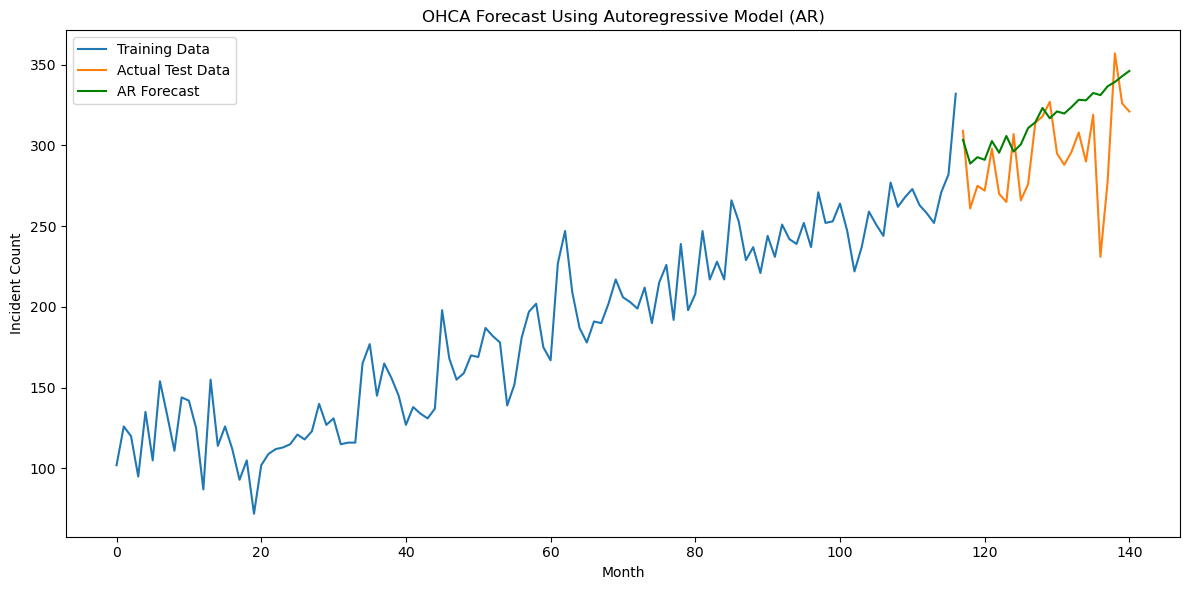

In [5]:
# training data
train_series = training_df['Incident Count (Month)']

# fit AR model with lag = 12 (monthly seasonality)
model = AutoReg(train_series, lags=12).fit()

# Forecast 24 months (2020–2021)
n_periods = len(testing_df)
y_forecast = model.predict(start=len(train_series),
                           end=len(train_series) + n_periods - 1).values

forecast_df = testing_df[["Month"]].copy()
forecast_df["Forecast"] = y_forecast.tolist()

# forecast_df = pd.DataFrame({
#     "Month": testing_df["Month"].values,
#     "Forecast": model.predict(start=len(train_series), end=len(train_series) + n_periods - 1).values
# }).set_index("Month")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(train_series, label='Training Data')
plt.plot(testing_df['Incident Count (Month)'], label='Actual Test Data')
plt.plot(forecast_df["Forecast"], label='AR Forecast', color='green')
plt.title('OHCA Forecast Using Autoregressive Model (AR)')
plt.xlabel('Month')
plt.ylabel('Incident Count')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
## to deal with cases where 0 will cause an error in smape calculation

def smape_function(y_true, y_predicted):
    y_true = np.array(y_true)
    y_predicted = np.array(y_predicted)
    denominator = np.abs(y_predicted) + np.abs(y_true)
    nonzero = denominator != 0
    return (100 * np.mean(
        2 * np.abs(y_predicted[nonzero] - y_true[nonzero]) / denominator[nonzero])
    )

##### Evaluating forecast accuracy

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = testing_df["Incident Count (Month)"]
y_predicted = forecast_df["Forecast"]

mae = mean_absolute_error(y_true, y_predicted)
rmse = np.sqrt(mean_squared_error(y_true, y_predicted))
# smape = 100 * np.mean(
#     2 * np.abs(y_predicted - y_true) /
#     (np.abs(y_predicted) + (np.abs(y_true)))
# )
smape = smape_function(y_true, y_predicted)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"SMAPE: {smape:.2f}%")


MAE: 25.53
RMSE: 32.69
SMAPE: 8.56%


based on the Symmetric Mean Absolute Percentage Error, accuracy of the auto regression model seems to be good. The forecast is off by about 25 incidents per month. Auto regression model seems to slightly underperform compared to Prophet. 

To look at the residual graph

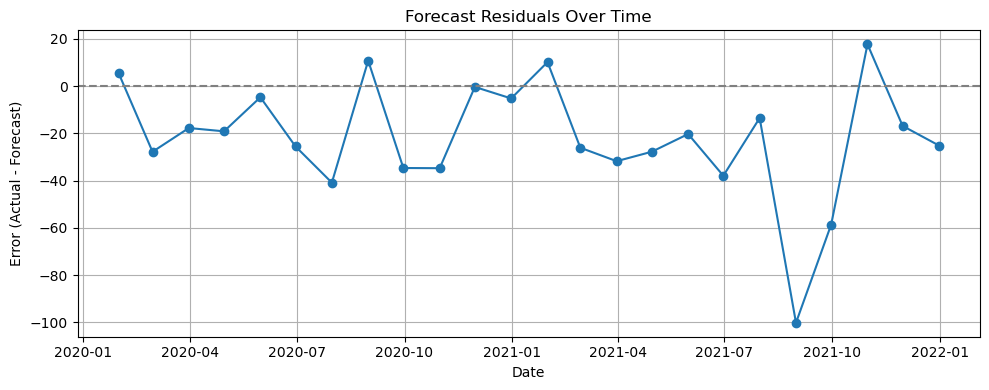

In [7]:
comparison = testing_df[["Month", "Incident Count (Month)"]].merge(forecast_df, on="Month", how = "left")
## residual = (actual - forecast)
comparison["residual"] = comparison["Incident Count (Month)"] - comparison["Forecast"]
plt.figure(figsize = (10, 4))
plt.plot(comparison["Month"], comparison["residual"], marker = 'o')
plt.axhline(0, linestyle = '--', color = "gray")
plt.title("Forecast Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Error (Actual - Forecast)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
# zooming in on 2021 June to Dec, the outlier forecast residual 
outlier_month = comparison[
    (comparison["Month"] >= "2021-06-01") &
    (comparison["Month"] <= "2021-12-31")
]

print(outlier_month)

        Month  Incident Count (Month)    Forecast    residual
17 2021-06-30                     290  327.912374  -37.912374
18 2021-07-31                     319  332.479694  -13.479694
19 2021-08-31                     231  331.144160 -100.144160
20 2021-09-30                     278  336.605143  -58.605143
21 2021-10-31                     357  339.263981   17.736019
22 2021-11-30                     326  342.825856  -16.825856
23 2021-12-31                     321  346.120838  -25.120838


### Using Expanding Window for comparision

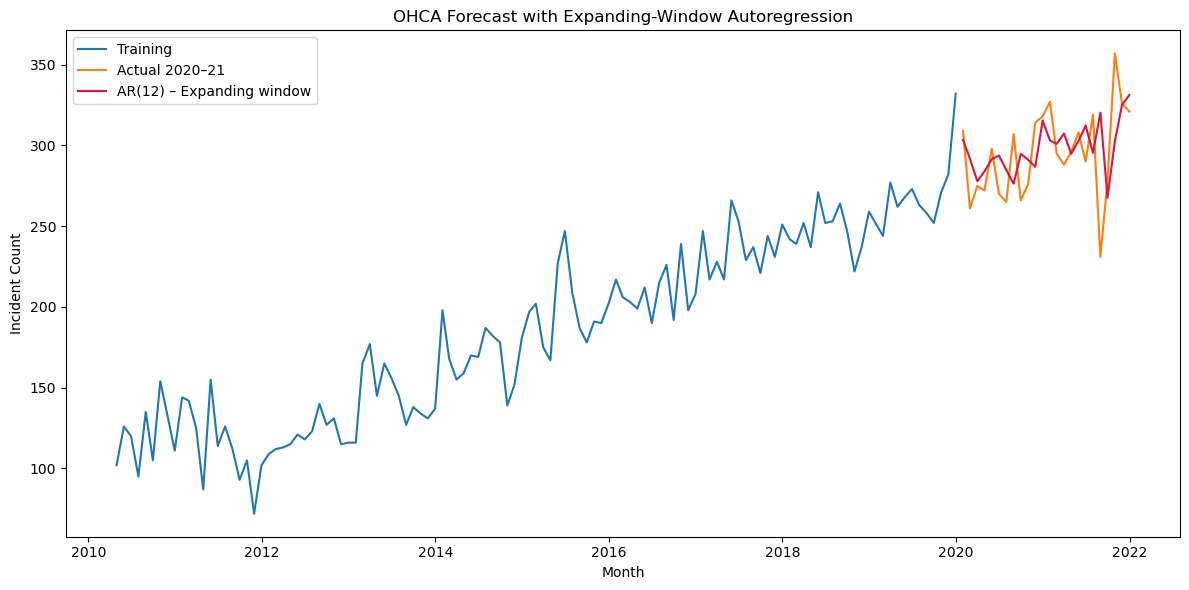

In [8]:
# split data
y_full   = count_by_month['Incident Count (Month)']          # whole series
y_train = training_df.set_index('Month')['Incident Count (Month)']
y_test  = testing_df.set_index('Month')['Incident Count (Month)']
dates_test = testing_df["Month"].values  

# expanding window forecast loop
lag = 12
history = list(y_train)

# store one-step forecast
exp_forecast = []

for i in range(len(y_test)):
    # fit autoregression(lag) on all data seen so far
    model = AutoReg(history, lags = lag, old_names = False).fit()

    # forecast one step ahead
    next_predicted = model.predict(
        start = len(history),
        # same value for 1-step forecast, predict only the next point
        end = len(history)
    )[0]

    exp_forecast.append(next_predicted)
    # append 'actual' observation to history so window 'expands'
    history.append(y_test.iloc[i])

# wrap forecast into dataframe
expanding_df = pd.DataFrame({
    "Month" : dates_test,
    "Forecast" : exp_forecast
})

expanding_df['Month'] = pd.to_datetime(expanding_df['Month'])

# print(y_train)
# plot
plt.figure(figsize=(12,6))
plt.plot(y_train.index, y_train, label='Training')
plt.plot(y_test.index, y_test, label='Actual 2020–21')
plt.plot(expanding_df['Month'], expanding_df['Forecast'], 
         label='AR(12) – Expanding window', color='crimson')
plt.title('OHCA Forecast with Expanding-Window Autoregression')
plt.xlabel('Month')
plt.ylabel('Incident Count')
plt.legend()
plt.tight_layout()
plt.show()

#### Evaluating Expanding Window forecast accuracy
Expanding Window seem to be performing slightly better than Prophet.

In [10]:
print(expanding_df)

        Month    Forecast
0  2020-01-31  303.425948
1  2020-02-29  291.732271
2  2020-03-31  277.863146
3  2020-04-30  283.849755
4  2020-05-31  291.465058
5  2020-06-30  293.745766
6  2020-07-31  284.815787
7  2020-08-31  276.291959
8  2020-09-30  294.753067
9  2020-10-31  291.134165
10 2020-11-30  286.818947
11 2020-12-31  315.376643
12 2021-01-31  303.037063
13 2021-02-28  300.977674
14 2021-03-31  307.340434
15 2021-04-30  294.789711
16 2021-05-31  302.700178
17 2021-06-30  312.310495
18 2021-07-31  295.441742
19 2021-08-31  320.222446
20 2021-09-30  267.544033
21 2021-10-31  302.635002
22 2021-11-30  325.026680
23 2021-12-31  331.204390


In [9]:
y_true = testing_df["Incident Count (Month)"]
y_predicted = expanding_df["Forecast"]

mae = mean_absolute_error(y_true, y_predicted)
rmse = np.sqrt(mean_squared_error(y_true, y_predicted))
smape = smape_function(y_true, y_predicted)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"SMAPE: {smape:.2f}%")

MAE: 19.68
RMSE: 27.44
SMAPE: 6.73%


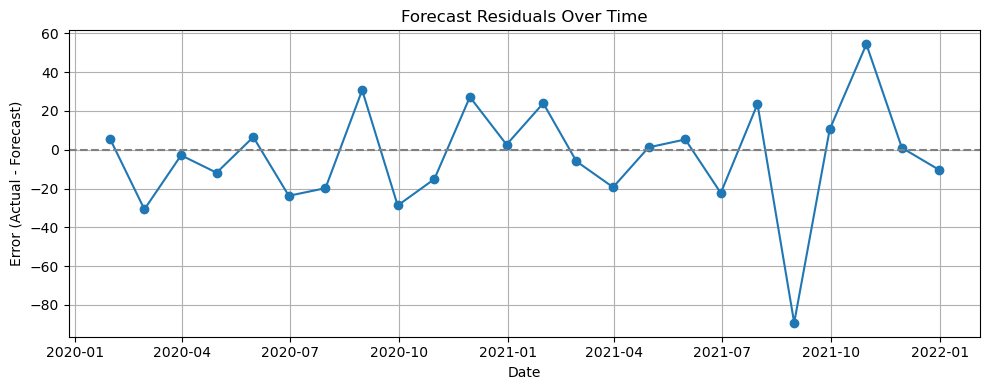

In [10]:
comparison = testing_df[["Month", "Incident Count (Month)"]].merge(expanding_df, on="Month", how = "left")
## residual = (actual - forecast)
comparison["residual"] = comparison["Incident Count (Month)"] - comparison["Forecast"]
plt.figure(figsize = (10, 4))
plt.plot(comparison["Month"], comparison["residual"], marker = 'o')
plt.axhline(0, linestyle = '--', color = "gray")
plt.title("Forecast Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Error (Actual - Forecast)")
plt.grid(True)
plt.tight_layout()
plt.show()

Similar to the forecast by Prophet and auto regression, there is a over prediction of cases at Aug - Sept, due to a dip in August.

#### Forecasting till 2040

In [11]:
def expanding_ar_forecast(history, forecast_horizon=1, lags=12):
    """
    history           list-like of observed values (or values + past forecasts)
    forecast_horizon  how many future months to predict in one go
    lags              AR order (12 = use last 12 months)

    Returns
    -------
    preds : list of length `forecast_horizon`
    """
    preds = []
    for _ in range(forecast_horizon):
        model = AutoReg(history, lags=lags, old_names=False).fit()
        next_val = model.predict(start=len(history), end=len(history))[0]
        preds.append(next_val)
        history.append(next_val)          # **expand** the window
    return preds

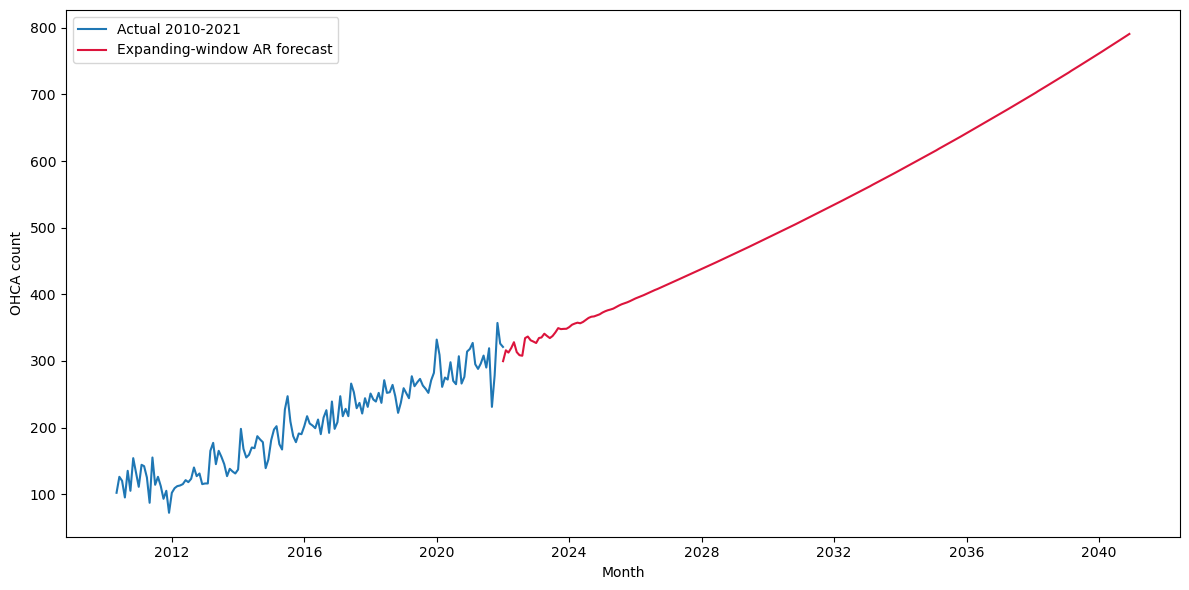

In [51]:

y_full = count_by_month.set_index('Month')['Incident Count (Month)']
# Then ensure:
y_full.index = pd.to_datetime(y_full.index)

# expanding window forecast loop
lag = 12
history = list(y_full)

# continue where the expanding window left off
# forecast January–December 2022
dates_2022 = pd.date_range('2022-01-01', '2022-12-01', freq='MS')
preds_2022 = expanding_ar_forecast(history, forecast_horizon=12, lags=12)

# store them
fc_2022 = pd.DataFrame({'Month': dates_2022, 'Forecast': preds_2022})

all_fc = [fc_2022]

# forecast 2023–2040 in yearly blocks
for year in range(2023, 2041):
    dates = pd.date_range(f'{year}-01-01', f'{year}-12-01', freq='MS')
    # history will keep growing as each forecast value is appended
    preds = expanding_ar_forecast(history, forecast_horizon=12, lags=12)
    all_fc.append(pd.DataFrame({'Month': dates, 'Forecast': preds}))

expanding_forecast = pd.concat(all_fc, ignore_index=True)

plt.figure(figsize=(12,6))
plt.plot(y_full.index, y_full, label='Actual 2010-2021')
plt.plot(expanding_forecast['Month'], expanding_forecast['Forecast'],
         label='Expanding-window AR forecast', color='crimson')
plt.xlabel('Month'); plt.ylabel('OHCA count'); plt.legend(); plt.tight_layout()
plt.show()


In [52]:
expanding_forecast["Month"] = pd.to_datetime(expanding_forecast["Month"]) + pd.offsets.MonthBegin(0)
print(expanding_forecast["Month"])

0     2022-01-01
1     2022-02-01
2     2022-03-01
3     2022-04-01
4     2022-05-01
         ...    
223   2040-08-01
224   2040-09-01
225   2040-10-01
226   2040-11-01
227   2040-12-01
Name: Month, Length: 228, dtype: datetime64[ns]


In [53]:
expanding_forecast["Year"] = expanding_forecast["Month"].dt.year
expanding_forecast["Quarter"] = expanding_forecast["Month"].dt.to_period("Q").astype(str)

print(expanding_forecast)

         Month    Forecast  Year Quarter
0   2022-01-01  299.605847  2022  2022Q1
1   2022-02-01  315.910615  2022  2022Q1
2   2022-03-01  312.484722  2022  2022Q1
3   2022-04-01  319.320561  2022  2022Q2
4   2022-05-01  328.074419  2022  2022Q2
..         ...         ...   ...     ...
223 2040-08-01  780.113347  2040  2040Q3
224 2040-09-01  782.791271  2040  2040Q3
225 2040-10-01  785.475257  2040  2040Q4
226 2040-11-01  788.165320  2040  2040Q4
227 2040-12-01  790.861472  2040  2040Q4

[228 rows x 4 columns]


In [57]:
forecast_by_year = expanding_forecast.groupby("Year")["Forecast"].sum().reset_index()

forecast_by_month = expanding_forecast.groupby("Month")["Forecast"].sum().reset_index()

forecast_by_quarter = expanding_forecast.groupby("Quarter")["Forecast"].sum().reset_index()

print(forecast_by_quarter)

   Quarter     Forecast
0   2022Q1   928.001183
1   2022Q2   960.555740
2   2022Q3   950.569507
3   2022Q4   996.628684
4   2023Q1   996.425941
..     ...          ...
71  2039Q4  2268.853659
72  2040Q1  2292.522994
73  2040Q2  2316.353438
74  2040Q3  2340.346089
75  2040Q4  2364.502049

[76 rows x 2 columns]


In [58]:
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2,  # x position (center of bar)
                height + 5,                        # y position (just above the bar)
                f'{height:.0f}',                   # label (no decimal)
                ha='center', va='bottom', fontsize=9)

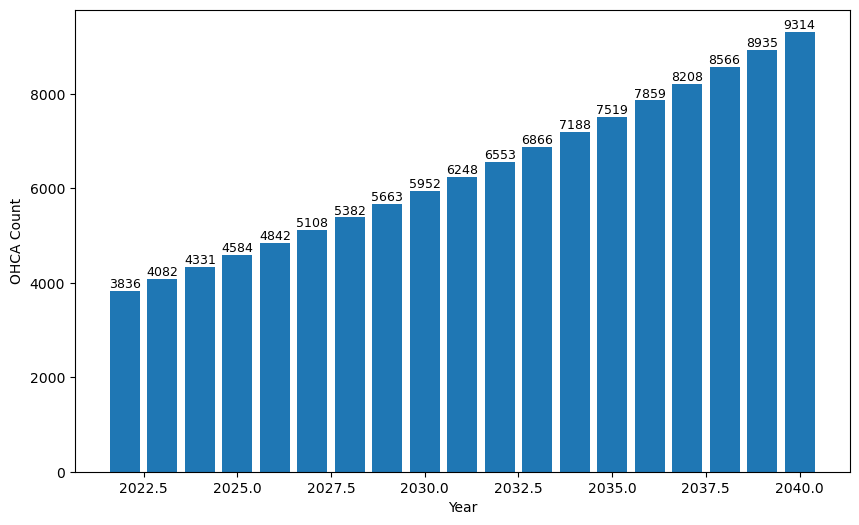

In [59]:
x = forecast_by_year["Year"]
y = forecast_by_year["Forecast"]
plt.figure(figsize = (10, 6))
bars = plt.bar(x, y)
add_labels(bars)
plt.xlabel("Year")
plt.ylabel("OHCA Count")
# plt.tight_layout()
plt.show()